# What drives used-car asking prices?
A CRISP-DM analysis for dealership inventory decisions.

## 1. Business understanding
Predict advertised price in US dollars from observable vehicle attributes and identify
associations useful for sourcing and pricing inventory. This is supervised regression.
Compare a median-price baseline, ridge regression, and polynomial features with Lasso.
Select models by training cross-validated dollar MAE, then evaluate on held-out vehicles.
The test partition is excluded from model fitting and hyperparameter tuning.
MAE is the average absolute dollar error; RMSE emphasizes expensive mistakes.
Asking prices are not completed transactions, willingness to pay, profit, or sales speed.
A successful analysis must beat the baseline and translate findings into cautious actions.
No collection date is supplied, so this is a historical cross-sectional study, not a
current-market price guide. Use model year directly rather than inventing vehicle age.

In [1]:
# Standard-library utilities handle dataset paths, configuration, and warnings.
from pathlib import Path
import os
import warnings
# NumPy supplies numerical operations; pandas handles tabular cleaning and summaries.
import numpy as np
import pandas as pd
# Seaborn supplies statistical plots; matplotlib manages axes and layouts.
import seaborn as sns
# Activate Jupyter's inline backend so figures are embedded in cell outputs.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
# Scikit-learn supplies leakage-aware pipelines, grouped validation, models, and metrics.
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.linear_model import Ridge, Lasso
from sklearn.exceptions import ConvergenceWarning
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# A nonconverged candidate must be fixed rather than silently accepted.
warnings.filterwarnings('error', category=ConvergenceWarning)
# Reuse a fixed seed for reproducible splits, sampled diagnostics, and bootstrap draws.
SEED = 42
# Locate the project when running either inside its folder or from the workspace root.
ROOT = Path.cwd()
if not (ROOT / 'prompt_II.ipynb').exists():
    ROOT = ROOT / 'Assignments/used_car_prices'
# Prefer the environment-specified CSV, then the repository data folder, then the
# original assignment location. The first existing path is used.
source_candidates = [Path(os.environ.get('VEHICLES_CSV', 'data/vehicles.csv')),
                     ROOT / 'data/vehicles.csv',
                     ROOT.parent.parent / 'data/practical_application_II_starter/data/vehicles.csv']
# Return None when no candidate exists so the next check gives a useful setup error.
SOURCE = next((p for p in source_candidates if p.is_file()), None)
if SOURCE is None:
    raise FileNotFoundError('Place vehicles.csv in data/ or set VEHICLES_CSV. See README.md.')
# Read the source once; later cleaning operates on a copy of this raw dataframe.
df = pd.read_csv(SOURCE)
# Apply a consistent visual style and readable default chart settings.
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
# Render explanations and charts directly inside the notebook.
from IPython.display import display, Markdown

def show_markdown(text):
    display(Markdown(text))

def show_figure():
    # Embed the current figure in notebook output without creating external files.
    plt.tight_layout()
    plt.show()
    plt.close()

# Confirm the expected dataset dimensions without printing individual listing records.
print(f'Loaded {len(df):,} listings and {len(df.columns)} columns.')
print('Columns:', ', '.join(df.columns))

Loaded 426,880 listings and 18 columns.
Columns: id, region, price, year, manufacturer, model, condition, cylinders, fuel, odometer, title_status, transmission, VIN, drive, size, type, paint_color, state


## 2. Data understanding
Inspect types, missing values, distributions, repeated VINs, and impossible values.
Report missingness instead of dropping every incomplete row: condition, cylinders,
size, drivetrain, and paint color are frequently absent. The dataset has no dates,
sale outcomes, dealer costs, trim-level normalization, or verified condition inspections.

Column types: {'str': 14, 'int64': 2, 'float64': 2}
Most incomplete attributes (%):
 size         71.8
cylinders    41.6
condition    40.8
VIN          37.7
drive        30.6

Numeric quantiles:
              price    year    odometer
0.00  0.000000e+00  1900.0         0.0
0.01  0.000000e+00  1967.0         2.0
0.05  0.000000e+00  1998.0      6318.0
0.50  1.395000e+04  2013.0     85548.0
0.95  4.450000e+04  2020.0    204000.0
0.99  6.699500e+04  2020.0    280000.0
1.00  3.736929e+09  2022.0  10000000.0

Zero prices: 32895
Nonmissing VIN rows: 265838 Distinct VIN strings: 118246


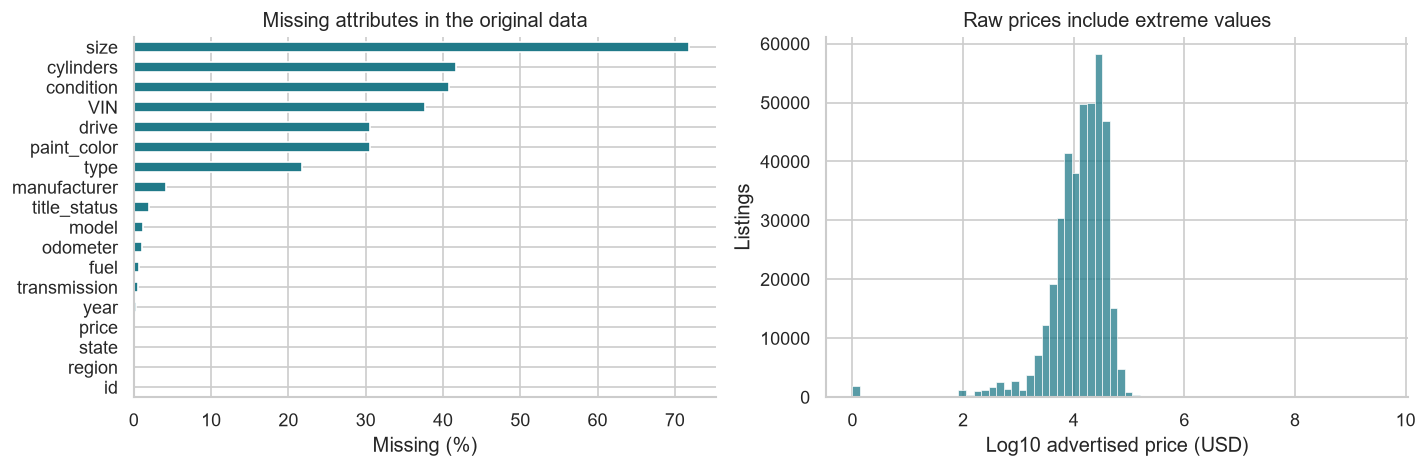

In [2]:
# isna() creates Boolean indicators; their column means are missing fractions.
# Convert them to percentages and rank the most incomplete attributes first.
missing = df.isna().mean().mul(100).sort_values(ascending=False).rename('missing_percent')
# Summarize types, missingness, quantiles, and repeated identifiers to identify
# quality issues before setting the modeling scope.
print('Column types:', df.dtypes.astype(str).value_counts().to_dict())
print('Most incomplete attributes (%):\n', missing.head(5).round(1).to_string())
print('\nNumeric quantiles:\n', df[['price','year','odometer']].quantile([0,.01,.05,.5,.95,.99,1]).to_string())
print('\nZero prices:', int(df.price.eq(0).sum()))
print('Nonmissing VIN rows:', df.VIN.notna().sum(), 'Distinct VIN strings:', df.VIN.nunique())
# Compare completeness and the raw price distribution side by side.
fig, axes = plt.subplots(1, 2, figsize=(12,4))
# Sort ascending for a horizontal plot so the largest missing percentage appears on top.
missing.sort_values().plot.barh(ax=axes[0], color='#207a89')
axes[0].set(xlabel='Missing (%)', title='Missing attributes in the original data')
# Plot only positive prices because log10(0) is undefined. The log scale makes
# extreme price values visible; this exploratory transform does not alter the target.
sns.histplot(x=np.log10(df.loc[df.price.gt(0), 'price']), bins=70, color='#207a89', ax=axes[1])
axes[1].set(xlabel='Log10 advertised price (USD)', ylabel='Listings', title='Raw prices include extreme values')
show_figure()

## 3. Data preparation
Define the scope as mainstream model years 1995–2022, asking prices $1,000–$100,000,
and recorded mileage between 100 and 350,000 miles. These are explicit business
boundaries, not estimated quantile cutoffs. They exclude many classics, unusually
expensive cars, likely down payments, and near-zero-mile listings. Missing year or
mileage remains eligible and is imputed within each training fold.

Normalize text. For plausible 17-character VINs, retain the first eligible listing
in source order (not the latest, because dates are unavailable). Remove duplicate
attributes/price listings, ignoring listing ID, VIN, and region. Group likely relistings
by manufacturer, model, year, mileage, body type, and paint color before splitting.
This may group distinct similar cars and cannot eliminate all unidentified relistings.
VIN and listing ID are identifiers and are excluded as predictors. Region is omitted
in favor of state; size is omitted because over 70% is missing. No outcome-based
feature selection or preprocessing is fitted on the test set.

In [3]:
# Work on a copy so the original, uncleaned dataframe remains available for comparison.
data = df.copy()
# Normalize text consistently: trim surrounding spaces, lowercase labels, and mark
# empty strings as missing. Pandas StringDtype preserves existing missing values.
for col in data.select_dtypes(include=['object', 'str']).columns:
    data[col] = data[col].astype('string').str.strip().str.lower().replace('', pd.NA)
# Record the starting row count; each cleaning step adds its own removal count.
audit = [{'step':'Original listings', 'remaining':len(data), 'removed':0}]
# Keep rows where the Boolean mask is True and log the effect of this filter.
# The function updates the shared working dataframe and appends to the audit list.
def retain(mask, label):
    # Rebinding data here must update the outer variable used by subsequent steps.
    global data
    before = len(data)
    data = data.loc[mask].copy()
    audit.append({'step':label, 'remaining':len(data), 'removed':before-len(data)})
# Apply the stated mainstream-market scope. between() includes both endpoints.
# These are business boundaries, not a claim that every excluded record is erroneous.
retain(data.price.between(1000,100000), 'Price between $1,000 and $100,000')
# Keep missing year/mileage values for later training-fold imputation. The | operator
# means either the value is missing OR it falls within the accepted interval.
retain(data.year.isna() | data.year.between(1995,2022), 'Year 1995–2022 or missing')
retain(data.odometer.isna() | data.odometer.between(100,350000), 'Mileage 100–350,000 or missing')
# Identify plausible 17-character VINs after lowercasing. VINs exclude I, O, and Q.
# This checks format only, not a VIN checksum; missing values are treated as invalid.
valid_vin = data.VIN.str.fullmatch(r'[a-hj-npr-z0-9]{17}', na=False)
# duplicated() flags later occurrences, leaving the first eligible source record.
# Restrict removal to plausible VINs so missing/invalid VINs do not collapse together.
# ~ negates the removal mask. Source order does not establish which listing is latest.
retain(~(valid_vin & data.VIN.where(valid_vin).duplicated()), 'First eligible listing per plausible VIN')
# Detect remaining duplicate listings using all other attributes, including price
# and state. Ignore listing ID, VIN, and region, which may vary across advertisements.
dedup_cols = [c for c in data.columns if c not in ['id','VIN','region']]
retain(~data.duplicated(subset=dedup_cols), 'Remove duplicate attributes and price')
# Give retained rows a fresh consecutive index; discard the old row-number column.
data = data.reset_index(drop=True)
# Export the cleaning history for reproducibility and show its compact summary.
audit = pd.DataFrame(audit)
print(audit.to_string(index=False))
# Separate numerical and categorical inputs for the later preprocessing pipelines.
numeric = ['year','odometer']
categorical = ['manufacturer','model','condition','cylinders','fuel','title_status',
               'transmission','drive','type','paint_color','state']
# Select predictors explicitly: price is the target, and identifiers are not inputs.
# Region and the highly incomplete size column are also excluded from the models.
features = numeric + categorical
X = data[features].copy()
# Preserve incomplete listings by representing missing categories as "unknown".
# Numerical imputation/scaling is learned later inside each training fold.
for c in categorical:
    X[c] = X[c].fillna('unknown').astype(str)
# Define the regression target in dollars. Log transformation happens in the models.
y = data.price.astype(float)
# Form a grouping key for likely relistings from vehicle attributes, excluding price.
# Identical fingerprints share a group even if their prices or locations differ.
# This is a heuristic: distinct similar cars can match, and some relistings can escape it.
fingerprint_cols = ['manufacturer','model','year','odometer','type','paint_color']
# Hash row values only; excluding the dataframe index lets matching rows share a key.
groups = pd.util.hash_pandas_object(X[fingerprint_cols], index=False).astype(str)
# Create one reproducible split that keeps each group entirely in train or test.
# test_size=.2 targets 20% of groups, so the row fraction can differ slightly.
# next() retrieves the single pair of positional index arrays from the split generator.
train_idx, test_idx = next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=SEED).split(X,y,groups))
# Apply the same positional indices to predictors and targets to preserve alignment.
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
# Retain training-group labels for grouped cross-validation during model selection.
g_train = groups.iloc[train_idx]
# Validate the intended invariants: no group leakage, prices within scope, and
# no repeated plausible VINs. A failed assertion stops execution for investigation.
assert set(g_train).isdisjoint(groups.iloc[test_idx])
assert data.price.between(1000,100000).all()
assert not data.loc[data.VIN.str.fullmatch(r'[a-hj-npr-z0-9]{17}',na=False),'VIN'].duplicated().any()
# Display split sizes and the overall cleaned-data median. This descriptive median
# is separate from the baseline model, which learns its median from training data only.
print(f'Training: {len(train_idx):,}; held-out test: {len(test_idx):,}; group overlap: 0')
print('Clean median price:', y.median())

                                    step  remaining  removed
                       Original listings     426880        0
       Price between $1,000 and $100,000     379910    46970
               Year 1995–2022 or missing     365005    14905
          Mileage 100–350,000 or missing     360001     5004
First eligible listing per plausible VIN     229742   130259
   Remove duplicate attributes and price     205928    23814
Training: 164,670; held-out test: 41,258; group overlap: 0
Clean median price: 11995.0


### Exploratory patterns in the training data
Use training records for substantive comparisons. The test partition is excluded
from model fitting and hyperparameter tuning. Category medians are unadjusted: brand, age, mileage, and body type
are entangled, so a median difference is not an independent price premium.

Training-data mileage summary (unadjusted):
              count   median
mileage_band                
<50k          34719  25990.0
50–100k       42028  14990.0
100–150k      46579   8995.0
150–200k      27828   6000.0
200–350k      12677   5000.0
Other descriptive tables remain available in the summaries dictionary.


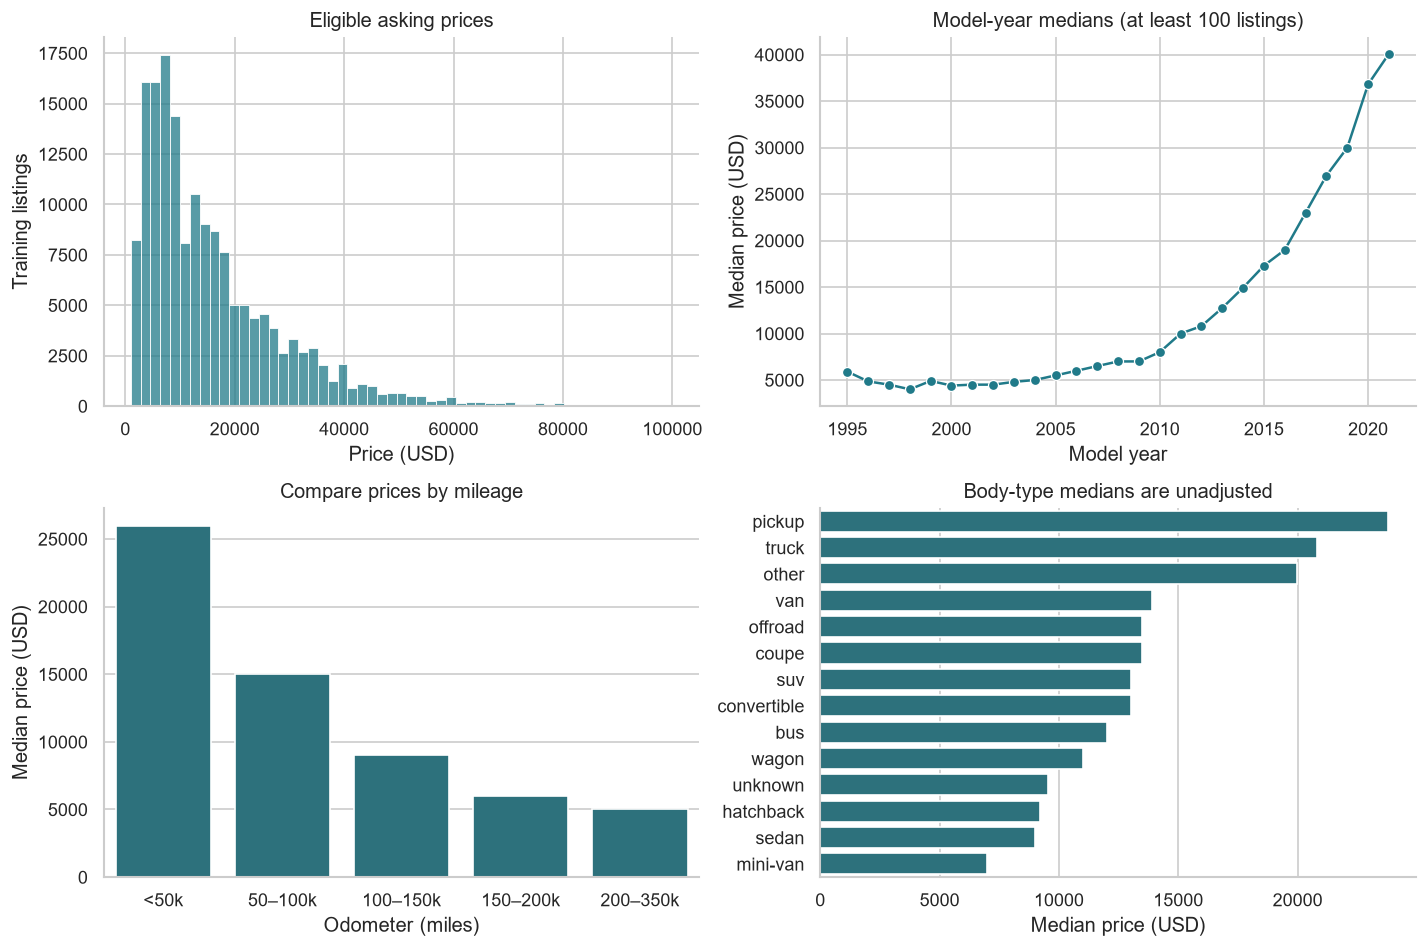

In [4]:
# Build an exploratory table from training records only, keeping the predictor
# matrix unchanged. Assignment by index aligns each row with its target price.
explore = X_train.copy()
explore['price'] = y_train
# Create ordered mileage bands for descriptive comparisons, not new model inputs.
# right=False uses [lower, upper) intervals; missing mileage remains unbinned.
explore['mileage_band'] = pd.cut(explore.odometer, [0,50000,100000,150000,200000,350000],
                               labels=['<50k','50–100k','100–150k','150–200k','200–350k'], right=False)
# Store reusable group summaries for plots and the dealer report.
summaries = {}
for col in ['year','mileage_band','manufacturer','condition','title_status','fuel','type','drive']:
    # Compute sample size, median, and mean by category. observed=True omits unused
    # categorical groups; these are unadjusted comparisons, not independent price effects.
    tab = explore.groupby(col, observed=True).price.agg(['count','median','mean']).sort_values('median',ascending=False)
    summaries[col] = tab
# Show one compact table; the other full summaries are available as CSV files.
print('Training-data mileage summary (unadjusted):')
print(summaries['mileage_band'].reindex(['<50k','50–100k','100–150k','150–200k','200–350k'])[['count','median']].to_string())
print('Other descriptive tables remain available in the summaries dictionary.')
# Use four panels to compare price distribution, model year, mileage, and body type.
fig, axes = plt.subplots(2,2,figsize=(12,8))
# The histogram shows the shape and concentration of eligible training asking prices.
sns.histplot(data=explore, x='price', bins=55, ax=axes[0,0], color='#207a89')
axes[0,0].set(title='Eligible asking prices',xlabel='Price (USD)',ylabel='Training listings')
# Require at least 100 listings per displayed year to avoid giving sparse groups
# the same visual prominence as well-supported years; retain all groups in the CSV.
year_summary = summaries['year'].query('count >= 100').sort_index().reset_index()
sns.lineplot(data=year_summary, x='year', y='median', marker='o', ax=axes[0,1], color='#207a89')
axes[0,1].set(title='Model-year medians (at least 100 listings)',xlabel='Model year',ylabel='Median price (USD)')
# Specify the logical mileage order instead of sorting these text labels alphabetically.
mileage_order = ['<50k','50–100k','100–150k','150–200k','200–350k']
# Plot precomputed medians with error bars disabled, rather than implying that
# seaborn estimated uncertainty from one summary row per category.
sns.barplot(data=summaries['mileage_band'].reset_index(), x='mileage_band', y='median',
            order=mileage_order, errorbar=None, ax=axes[1,0], color='#207a89')
axes[1,0].set(title='Compare prices by mileage',xlabel='Odometer (miles)',ylabel='Median price (USD)')
# Display sufficiently populated body types in descending median-price order.
type_summary = summaries['type'].query('count >= 100').sort_values('median', ascending=False).reset_index()
# Each row already contains a group median; disable seaborn's estimator uncertainty.
sns.barplot(data=type_summary, x='median', y='type', order=type_summary['type'],
            errorbar=None, ax=axes[1,1], color='#207a89')
axes[1,1].set(title='Body-type medians are unadjusted',xlabel='Median price (USD)',ylabel='')
show_figure()

## 4. Modeling
Fit all imputers and encoders inside cross-validation pipelines. Ridge standardizes
numeric inputs and one-hot encodes categorical values, pooling rare categories.
Polynomial Lasso imputes and standardizes year and mileage before forming squared
and cubic terms, including their interactions. Categorical attributes are separately
one-hot encoded; no polynomial expansion is applied to category columns. Two binary
indicators preserve whether year or mileage was missing. A final sparse-compatible
StandardScaler gives every expanded feature unit variance before L1 regularization.
Both models pool rare categories with at most 300 encoded categories per attribute.
Unseen categories use the learned rare-category bucket when available, otherwise
all-zero encoding. Model-name detail is therefore incomplete for uncommon vehicles.

Both regressors predict log(1 + price), reducing the influence of expensive listings.
Evaluate inverse-transformed predictions in dollars. Log-target fitting can underpredict
expensive vehicles and does not estimate an unbiased conditional mean dollar price.

Three-fold GroupKFold keeps likely relistings together. Search ridge alpha values
[1, 100, 1000] and polynomial Lasso degrees [2, 3] with alpha [0.0001, 0.001, 0.01].
The ten configurations including the baseline produce 30 fold fits plus three refits.
Choose the lowest training-CV MAE, not the lowest test error. Lasso uses at most 5,000
iterations and tolerance 0.0001; convergence warnings are treated as errors.

**Primary metric: mean absolute error (MAE), in dollars.**
MAE = mean(abs(actual price - predicted price)). A dealer can interpret it directly
as the average size of a pricing error. It gives equal cost to equal dollar errors
and is less dominated by extreme listings than squared error. It is not a profit
metric. RMSE is a secondary check on large mistakes; R² describes fit but cannot
express a dealer's dollar exposure. Do not use log-scale error for model selection.

In [5]:
# Ridge fills numerical gaps with training medians, records observed missingness,
# and standardizes numerical values and the generated missingness indicators.
num_pipe = Pipeline([('impute',SimpleImputer(strategy='median',add_indicator=True)),
                     ('scale',StandardScaler())])
# Apply different preprocessing to numerical and categorical columns. Rare
# categories are pooled; fitted encoders handle unfamiliar validation categories.
ridge_pre = ColumnTransformer([
    ('numeric',num_pipe,numeric),
    ('categorical',OneHotEncoder(handle_unknown='infrequent_if_exist',min_frequency=25,max_categories=300),categorical)])
# Fit ridge to log(1 + price). predict() automatically reverses this transform
# with expm1, so cross-validation scores are calculated in dollars.
ridge = TransformedTargetRegressor(
    regressor=Pipeline([('preprocess',ridge_pre),('model',Ridge(solver='lsqr'))]),
    func=np.log1p,inverse_func=np.expm1)
# Center before taking powers to avoid poorly conditioned powers of calendar years.
# Standardize the two original inputs before polynomial expansion. include_bias=False
# omits a constant feature because the regression model already fits an intercept.
poly_numeric = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('center_scale', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False))])
# Combine numerical polynomial terms, two missingness flags, and one-hot categories.
# PolynomialFeatures never receives categorical columns or missingness flags.
lasso_pre = ColumnTransformer([
    ('numeric', poly_numeric, numeric),
    ('missing', MissingIndicator(features='all'), numeric),
    ('categorical', OneHotEncoder(handle_unknown='infrequent_if_exist',
                                 min_frequency=25, max_categories=300), categorical)])
# Lasso penalizes coefficient magnitude and can set coefficients exactly to zero.
# with_mean=False preserves the sparse matrix while scaling expanded features;
# cyclic coordinate descent and explicit iteration limits control optimization.
polynomial_lasso = TransformedTargetRegressor(
    regressor=Pipeline([
        ('preprocess', lasso_pre),
        ('scale', StandardScaler(with_mean=False)),
        ('model', Lasso(max_iter=5000, tol=1e-4, selection='cyclic', random_state=SEED))]),
    func=np.log1p, inverse_func=np.expm1)
# Keep related records together in each of three validation folds.
cv = GroupKFold(n_splits=3)
# Define the baseline and parameter grids. Double underscores address parameters
# inside nested estimators/pipelines, including the degree of polynomial expansion.
specs = {
    'Median baseline':(DummyRegressor(strategy='median'),{}),
    'Log-price ridge':(ridge,{'regressor__model__alpha':[1,100,1000]}),
    'Log-price polynomial Lasso':(polynomial_lasso, {
        'regressor__preprocess__numeric__poly__degree':[2,3],
        'regressor__model__alpha':[0.0001,0.001,0.01]})}
# Keep each fitted search object for prediction and its complete CV results for audit.
searches, cv_rows = {}, []
for name,(estimator,grid) in specs.items():
    print('Fitting',name,flush=True)
    # Scikit-learn maximizes scores, so negative MAE makes smaller dollar error better.
    # Fit failures raise immediately; n_jobs=1 runs candidate fits sequentially.
    # The default refit=True retrains the best configuration on all training records.
    search = GridSearchCV(estimator,grid,scoring='neg_mean_absolute_error',cv=cv,n_jobs=1,return_train_score=True,error_score='raise')
    # Pass group labels into CV. Each fold learns its own preprocessing from training
    # rows only; test-set outcomes are not used to tune these configurations.
    search.fit(X_train,y_train,groups=g_train)
    searches[name] = search
    # Collect fold scores, averages, variability, parameters, and timing for every candidate.
    r = pd.DataFrame(search.cv_results_)
    r.insert(0,'model',name)
    cv_rows.append(r)
    print('Best CV MAE:',round(-search.best_score_,2),'Parameters:',search.best_params_,flush=True)
# Combine results across model families into one reproducible comparison table.
cv_results = pd.concat(cv_rows,ignore_index=True)
# Choose the largest negative-MAE score, which is the smallest cross-validated MAE.
# This selection is independent of the subsequently reported test scores.
winner = max(searches,key=lambda k:searches[k].best_score_)
best = searches[winner].best_estimator_
print('Selected using training CV only:',winner)

Fitting Median baseline
Best CV MAE: 9444.14 Parameters: {}
Fitting Log-price ridge
Best CV MAE: 3890.52 Parameters: {'regressor__model__alpha': 1}
Fitting Log-price polynomial Lasso
Best CV MAE: 3817.43 Parameters: {'regressor__model__alpha': 0.001, 'regressor__preprocess__numeric__poly__degree': 3}
Selected using training CV only: Log-price polynomial Lasso


### Interpreting the ridge coefficients
Ridge predicts log(1 + price), not dollar price. Numeric predictors are standardized,
so divide each fitted coefficient by its training standard deviation before expressing
a change of one model year or 10,000 miles. For log change d, 100 * (exp(d) - 1)
is the exact percentage change in predicted (price + 1), approximately the percentage
change in price at these price levels, with other encoded inputs held fixed.

All one-hot categories are retained. A categorical coefficient alone is therefore
not a comparison against an omitted reference group. Subtract the two category
coefficients for an explicit contrast. The intercept is not a realistic base car.
Correlated features, regularization, category pooling, and linear-model assumptions
limit interpretation. These are fitted conditional associations, not causal effects,
and no coefficient significance tests or confidence intervals are claimed.

In [6]:
# Retrieve the fitted inner pipeline, not the unfitted estimator template.
# regressor_ is the trained object inside TransformedTargetRegressor.
fitted_ridge = searches['Log-price ridge'].best_estimator_.regressor_
ridge_preprocessor = fitted_ridge.named_steps['preprocess']
# Match every fitted coefficient to the exact transformed feature name and order.
coefficient_names = ridge_preprocessor.get_feature_names_out()
coefficients = pd.Series(fitted_ridge.named_steps['model'].coef_, index=coefficient_names)
# Retrieve training-fold-refit standard deviations to undo numerical input scaling.
scales = ridge_preprocessor.named_transformers_['numeric'].named_steps['scale'].scale_
# Express numerical effects for useful changes: one model year or 10,000 miles.
contrasts = []
for feature, amount, label in [('year', 1, 'One model year newer'),
                               ('odometer', 10000, '10,000 additional miles')]:
    # Convert the original-unit change into standardized units, then multiply by beta.
    # expm1(log_change) below converts the log change into a relative change in price + 1.
    log_change = coefficients[f'numeric__{feature}'] * amount / scales[numeric.index(feature)]
    contrasts.append({'comparison': label, 'log_change': log_change,
                      'percent_change_price_plus_1': 100 * np.expm1(log_change)})
# Compare explicit category pairs; no category was dropped as a reference level,
# so an isolated one-hot coefficient is not itself a reference-category premium.
for feature, category, reference_category in [('drive', '4wd', 'fwd'),
        ('fuel', 'diesel', 'gas'), ('condition', 'excellent', 'good'),
        ('title_status', 'clean', 'salvage')]:
    # Both categories must have explicit columns, rather than a pooled rare-category column.
    category_key = f'categorical__{feature}_{category}'
    reference_key = f'categorical__{feature}_{reference_category}'
    if category_key in coefficients.index and reference_key in coefficients.index:
        # Subtract the reference coefficient while holding the remaining encoded inputs fixed.
        log_change = coefficients[category_key] - coefficients[reference_key]
        contrasts.append({'comparison': f'{feature}: {category} vs {reference_category}',
                          'log_change': log_change,
                          'percent_change_price_plus_1': 100 * np.expm1(log_change)})
coefficient_contrasts = pd.DataFrame(contrasts)
print(coefficient_contrasts.round(3).to_string(index=False))
# Use the calculated effects in the narrative. Multiplying by 15,001 illustrates
# the dollar change from a hypothetical $15,000 prediction on the price + 1 scale.
year_effect, mileage_effect = coefficient_contrasts.iloc[:2].percent_change_price_plus_1
show_markdown(f"The fitted ridge model associates **one newer model year with {year_effect:+.1f}%** "
              f"and **10,000 additional miles with {mileage_effect:+.1f}%** in predicted price + 1, "
              "holding other encoded attributes fixed. For a hypothetical starting prediction of $15,000, "
              f"the corresponding dollar changes are approximately **${15001 * year_effect / 100:+,.0f}** "
              f"and **${15001 * mileage_effect / 100:+,.0f}**. These illustrate the linear model, "
              "not universal depreciation rules. Polynomial Lasso is interpreted separately below "
              "because its powers and interactions make numeric effects depend on the starting vehicle.")

                    comparison  log_change  percent_change_price_plus_1
          One model year newer       0.074                        7.716
       10,000 additional miles      -0.038                       -3.767
             drive: 4wd vs fwd       0.178                       19.444
           fuel: diesel vs gas       0.661                       93.599
  condition: excellent vs good       0.137                       14.720
title_status: clean vs salvage       0.285                       32.951


The fitted ridge model associates **one newer model year with +7.7%** and **10,000 additional miles with -3.8%** in predicted price + 1, holding other encoded attributes fixed. For a hypothetical starting prediction of $15,000, the corresponding dollar changes are approximately **$+1,157** and **$-565**. These illustrate the linear model, not universal depreciation rules. Polynomial Lasso is interpreted separately below because its powers and interactions make numeric effects depend on the starting vehicle.

### Interpreting polynomial Lasso and feature selection
Let z_year and z_mileage be the two inputs standardized with training statistics.
PolynomialFeatures builds powers and interactions of these z variables. The table
below reports coefficients divided by the final feature scaler: each coefficient
multiplies its named z-basis term in log(1 + price). For example, numeric__year^2
multiplies z_year squared, not raw calendar year squared. A single coefficient is
not a global per-year or per-mile effect; all affected powers/interactions must change.

Lasso can set coefficients exactly to zero. A zero means this fitted regularized
model omitted the encoded term, not that the underlying attribute is unimportant
to buyers. Correlated terms may substitute for one another. No coefficient p-values
or significance claims are made. Finite-change examples use a real training record
as their starting point, keep its other attributes fixed, and report model responses.

In [7]:
# Retrieve the best Lasso pipeline after refitting on all training records.
fitted_lasso = searches['Log-price polynomial Lasso'].best_estimator_.regressor_
# Align transformed term names, fitted coefficients, and final scaler values.
lasso_names = fitted_lasso.named_steps['preprocess'].get_feature_names_out()
lasso_values = fitted_lasso.named_steps['model'].coef_
lasso_scales = fitted_lasso.named_steps['scale'].scale_
# Divide by the final scaler to express each beta on the standardized-input
# polynomial basis (or the unscaled indicator). This does not undo the initial
# standardization of year/mileage. Exact zero coefficients identify omitted terms.
lasso_coefficients = pd.DataFrame({
    'term': lasso_names, 'scaled_coefficient': lasso_values,
    'coefficient_on_z_basis_or_indicator': lasso_values / lasso_scales,
    'retained': lasso_values != 0})
# Keep the full coefficient table on disk; only the short numerical-term subset
# is printed in the notebook.
# Count retained encoded terms, not original attributes: one attribute may create
# several terms, and zeroing one term does not eliminate the whole attribute.
selected_count = int(lasso_coefficients.retained.sum())
total_count = len(lasso_coefficients)
print(f'Lasso retained {selected_count} of {total_count} encoded terms.')
print(lasso_coefficients[lasso_coefficients.term.str.startswith('numeric__')]
      [['term','coefficient_on_z_basis_or_indicator','retained']].round(4).to_string(index=False))
# Check that the chosen fit finished before the iteration cap; convergence
# warnings have already been configured to stop unsuccessful fits.
assert fitted_lasso.named_steps['model'].n_iter_ < 5000
# Recover the initial input centering/scaling used to define z_year and z_mileage.
numeric_fit = fitted_lasso.named_steps['preprocess'].named_transformers_['numeric']
center = numeric_fit.named_steps['center_scale']
# Choose the first eligible training record deterministically for a worked example.
# Double brackets preserve a one-row dataframe with the model input schema.
example = X_train.loc[X_train.year.between(2005,2019) & X_train.odometer.between(20000,200000)].iloc[[0]].copy()
# Compute the starting dollar prediction before changing either numerical input.
reference_prediction = float(searches['Log-price polynomial Lasso'].predict(example)[0])
# Evaluate one change at a time. The full pipeline recomputes all affected powers
# and interactions, giving a record-specific effect rather than a global slope.
changes = []
for feature, amount, label in [('year',1,'One model year newer'),
                              ('odometer',10000,'10,000 additional miles')]:
    # Reset to the same starting record so the two hypothetical changes are independent.
    changed = example.copy()
    changed[feature] += amount
    changed_prediction = float(searches['Log-price polynomial Lasso'].predict(changed)[0])
    # Store both dollar differences and the relative change in predicted price + 1,
    # consistent with the logarithmic target used during fitting.
    changes.append({'comparison':label,'starting_year':float(example.year.iloc[0]),
                    'starting_mileage':float(example.odometer.iloc[0]),
                    'base_prediction':reference_prediction,'changed_prediction':changed_prediction,
                    'dollar_change':changed_prediction-reference_prediction,
                    'percent_change_price_plus_1':100*((changed_prediction+1)/(reference_prediction+1)-1)})
lasso_examples = pd.DataFrame(changes)
print(lasso_examples[['comparison','dollar_change','percent_change_price_plus_1']].round(2).to_string(index=False))
# Report the selected hyperparameters and training-derived standardization alongside
# the example context so the coefficient interpretation can be reproduced.
show_markdown(f"**Polynomial Lasso retained {selected_count} of {total_count} encoded terms.** "
              f"Its selected degree is **{numeric_fit.named_steps['poly'].degree}** and alpha is "
              f"**{fitted_lasso.named_steps['model'].alpha}**. The numerical basis uses "
              f"z_year = (year − {center.mean_[0]:.2f}) / {center.scale_[0]:.2f} and "
              f"z_mileage = (mileage − {center.mean_[1]:,.0f}) / {center.scale_[1]:,.0f}. "
              f"The finite-change examples start from a {int(example.year.iloc[0])} vehicle with "
              f"{example.odometer.iloc[0]:,.0f} miles and a predicted price of ${reference_prediction:,.0f}. "
              "Their effects are specific to that starting record and are not universal premiums. "
              "Lasso's selection and these interpretations use the training-fitted model.")

Lasso retained 409 of 465 encoded terms.
                    term  coefficient_on_z_basis_or_indicator  retained
           numeric__year                               0.5120      True
       numeric__odometer                              -0.2580      True
         numeric__year^2                               0.0067      True
  numeric__year odometer                               0.0055      True
     numeric__odometer^2                              -0.0047      True
         numeric__year^3                              -0.0308      True
numeric__year^2 odometer                              -0.0044      True
numeric__year odometer^2                               0.0009      True
     numeric__odometer^3                               0.0151      True
             comparison  dollar_change  percent_change_price_plus_1
   One model year newer        1766.96                         9.28
10,000 additional miles        -730.43                        -3.84


**Polynomial Lasso retained 409 of 465 encoded terms.** Its selected degree is **3** and alpha is **0.001**. The numerical basis uses z_year = (year − 2011.15) / 5.70 and z_mileage = (mileage − 107,578) / 62,029. The finite-change examples start from a 2010 vehicle with 71,229 miles and a predicted price of $19,036. Their effects are specific to that starting record and are not universal premiums. Lasso's selection and these interpretations use the training-fitted model.

## 5. Evaluation
Evaluate on the test partition, excluded from model fitting and hyperparameter tuning. Compare dollar MAE, RMSE, and R², inspect residuals and
segment errors, and estimate sampling uncertainty using a vehicle-group bootstrap.
The interval quantifies this test sample's uncertainty, not geographic or future-market
generalization. All candidate test scores are reported for transparency; selection
remains the training-CV decision. Do not tune models against these results. Validate
performance on external or later-period data before operational use.

                     model   cv_MAE  test_MAE  test_RMSE  test_R2
           Median baseline 9444.138  9384.706  13663.454   -0.088
           Log-price ridge 3890.523  3895.804   6819.401    0.729
Log-price polynomial Lasso 3817.429  3829.135   6728.681    0.736
95% group-bootstrap MAE interval: [3763. 3891.]
Within $3,000: 0.633

Error by actual price:
                  count      MAE  bias_actual_minus_pred
price_band                                             
[0, 10000)       18121   1851.0                  -934.0
[10000, 20000)   12025   2980.0                   547.0
[20000, 40000)    8935   6143.0                  2919.0
[40000, 100001)   2177  15487.0                  8982.0


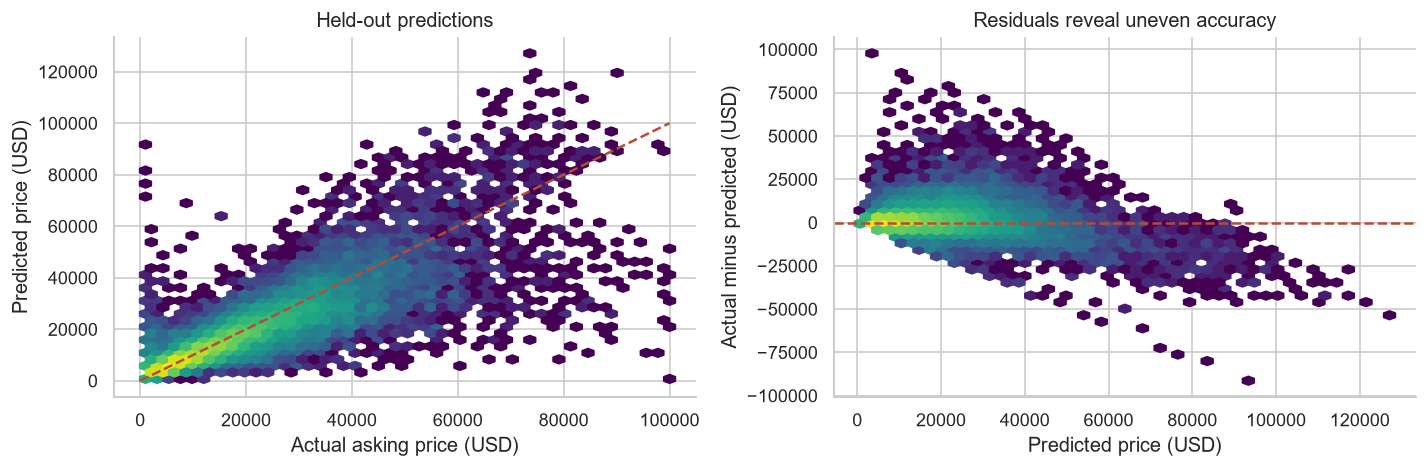

In [8]:
# Evaluate the already-fitted model families; do not refit or retune on test data.
metrics, predictions = [], {}
for name,search in searches.items():
    # These predictions are in dollars because the target wrapper applies expm1.
    pred = search.predict(X_test)
    predictions[name] = pred
    # MAE measures average absolute error, RMSE emphasizes large errors, and R² compares
    # squared error with predicting the test mean. Negate CV score to recover positive MAE.
    metrics.append({'model':name,'cv_MAE':-search.best_score_,
                    'test_MAE':mean_absolute_error(y_test,pred),
                    'test_RMSE':root_mean_squared_error(y_test,pred),'test_R2':r2_score(y_test,pred)})
# Save full-precision scores and round only their notebook presentation.
metrics = pd.DataFrame(metrics)
print(metrics.round(3).to_string(index=False))
# Use the CV-selected model for all following residual and segment diagnostics.
pred = predictions[winner]
# Positive residuals (actual minus predicted) mean underprediction. Convert targets
# to arrays to retain positional alignment with the prediction array.
errors = pd.DataFrame({'actual':y_test.to_numpy(),'predicted':pred,
                       'absolute_error':np.abs(y_test.to_numpy()-pred),
                       'residual':y_test.to_numpy()-pred,'group':groups.iloc[test_idx].to_numpy()})
# Aggregate errors within vehicle groups before resampling, preserving related
# records as a unit instead of incorrectly treating all rows as independent.
bygroup = errors.groupby('group').absolute_error.agg(['sum','count'])
# Create a reproducible generator for the group bootstrap without altering other RNGs.
rng = np.random.default_rng(SEED)
boot = []
# Draw 400 bootstrap samples of groups, with replacement. Divide total error by
# total sampled rows to estimate row-weighted MAE, not the mean of group means.
for _ in range(400):
    sample = rng.integers(0,len(bygroup),len(bygroup))
    boot.append(bygroup['sum'].to_numpy()[sample].sum()/bygroup['count'].to_numpy()[sample].sum())
# Take the bootstrap 2.5th and 97.5th percentiles as an interval for average error.
# This is conditional on the fitted model and sample, not an individual price interval.
ci = np.quantile(boot,[.025,.975])
print('95% group-bootstrap MAE interval:',ci.round(0))
print('Within $3,000:',round(errors.absolute_error.le(3000).mean(),3))
# Check whether average error and directional bias differ by vehicle type,
# condition, or state; an overall score can hide poorly served segments.
segment_errors = []
for feature in ['type','condition','state']:
    t = errors.assign(segment=X_test[feature].to_numpy()).groupby('segment').agg(
        count=('actual','size'),MAE=('absolute_error','mean'),bias_actual_minus_pred=('residual','mean'))
    t.insert(0,'feature',feature)
    segment_errors.append(t.reset_index())
segment_errors = pd.concat(segment_errors,ignore_index=True)
# Diagnose errors by actual-price tier. The final bin includes the $100,000 scope
# limit by using an exclusive upper endpoint of 100,001.
price_errors = errors.assign(price_band=pd.cut(errors.actual,[0,10000,20000,40000,100001],right=False)).groupby('price_band',observed=True).agg(count=('actual','size'),MAE=('absolute_error','mean'),bias_actual_minus_pred=('residual','mean'))
print('\nError by actual price:\n',price_errors.round(0).to_string())
# Hexagonal density plots reduce overplotting; bins="log" scales cell counts,
# not the dollar axes. mincnt=1 hides empty cells.
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hexbin(errors.actual,errors.predicted,gridsize=45,bins='log',cmap='viridis',mincnt=1)
# The diagonal marks perfect predictions over the observed price scope.
axes[0].plot([0,100000],[0,100000],color='#b84b35',ls='--')
axes[0].set(xlabel='Actual asking price (USD)',ylabel='Predicted price (USD)',title='Held-out predictions')
axes[1].hexbin(errors.predicted,errors.residual,gridsize=45,bins='log',cmap='viridis',mincnt=1)
# Zero residual is the reference line for judging underprediction and overprediction.
axes[1].axhline(0,color='#b84b35',ls='--')
axes[1].set(xlabel='Predicted price (USD)',ylabel='Actual minus predicted (USD)',title='Residuals reveal uneven accuracy')
show_figure()

### Which attributes contribute predictive information?
Permute one raw attribute at a time in a fixed random sample of up to 5,000 test
listings, repeated five times. The increase in MAE measures model reliance, not
causality or an independent dollar premium. Correlated variables can share importance.
For direction, show descriptive medians alongside model sensitivity to year and mileage.
Sensitivity changes one input while holding others fixed; some synthetic combinations
may be uncommon. These are model responses, not causal depreciation estimates.

     feature  MAE_increase  repeat_std
        year        3989.5        22.9
    odometer        1426.7        40.8
       model         728.7        37.4
        fuel         707.7        17.8
manufacturer         693.2        26.3
   cylinders         431.6        20.4
   condition         250.0         9.5
       drive         202.7        14.2
        type         164.7        13.9
title_status          88.4         8.6
       state          79.5        18.9
transmission          28.2         4.0
 paint_color           3.9         1.6


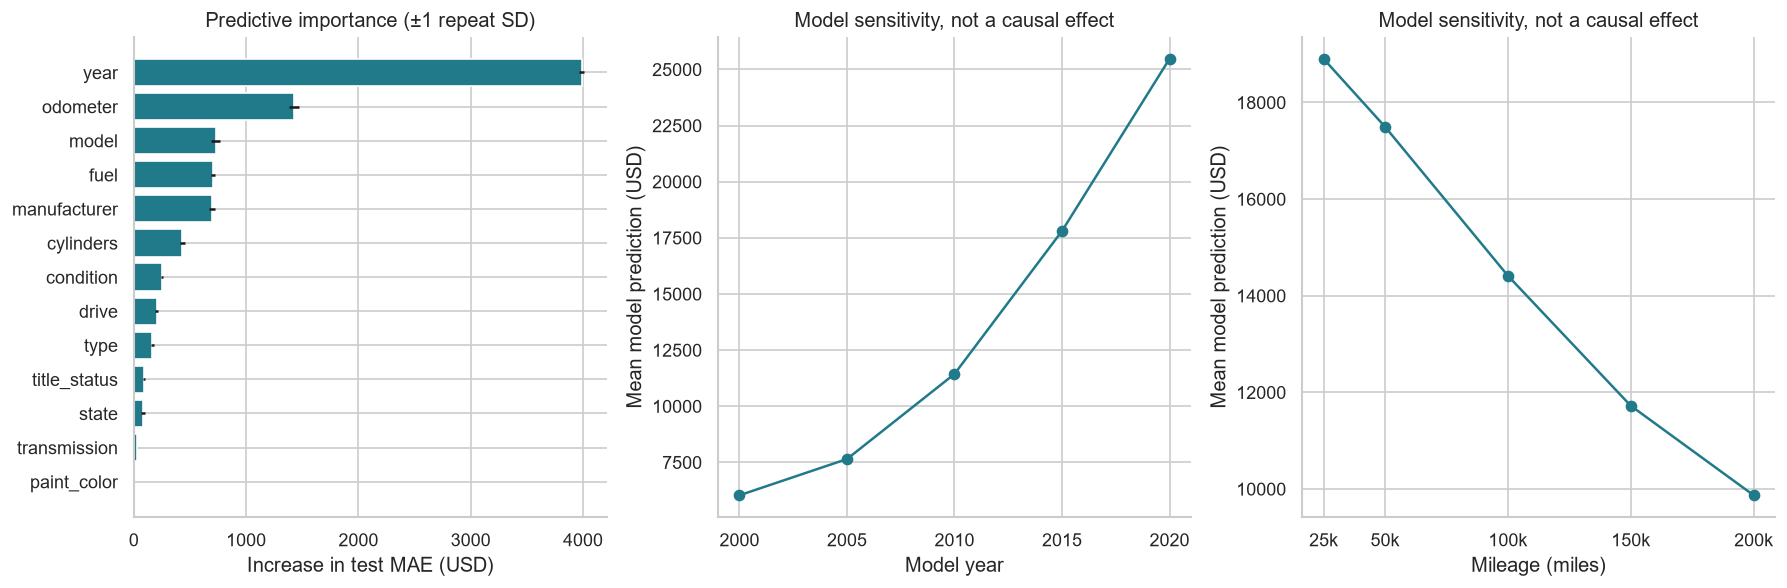

In [9]:
# Use a fixed-size reproducible test sample to keep permutation diagnostics practical.
# Select targets by the same dataframe indices to preserve row alignment.
sample_X = X_test.sample(min(5000,len(X_test)),random_state=SEED)
# Shuffle each raw input five times and measure the deterioration in negative MAE.
# A positive importance therefore means an increase in dollar error after shuffling;
# correlated inputs can share importance, and the result is not a causal premium.
perm = permutation_importance(best,sample_X,y_test.loc[sample_X.index],
                              scoring='neg_mean_absolute_error',n_repeats=5,random_state=SEED,n_jobs=1)
# Summarize the mean change and variation across shuffles, then rank features.
importance = pd.DataFrame({'feature':features,'MAE_increase':perm.importances_mean,
                           'repeat_std':perm.importances_std}).sort_values('MAE_increase',ascending=False)
print(importance.round(1).to_string(index=False))
# Explore the selected model response on a reproducible sample of training vehicles.
sensitivity = []
reference = X_train.sample(min(2000,len(X_train)),random_state=SEED)
for feature,values in [('year',[2000,2005,2010,2015,2020]),('odometer',[25000,50000,100000,150000,200000])]:
    for value in values:
        # Set one raw attribute to a common value while retaining the other attributes.
        # The pipeline recomputes derived terms; synthetic combinations may be uncommon.
        altered=reference.copy()
        altered[feature]=value
        # Average predictions across the reference vehicles to summarize model sensitivity,
        # not a causal depreciation estimate or a prediction for one particular car.
        sensitivity.append({'feature':feature,'value':value,'mean_prediction':float(best.predict(altered).mean())})
sensitivity=pd.DataFrame(sensitivity)
# Place predictive importance next to year and mileage response curves.
fig,axes=plt.subplots(1,3,figsize=(15,5))
p=importance.sort_values('MAE_increase')
# Error bars show one standard deviation across permutation repeats, not a 95% CI.
axes[0].barh(p.feature,p.MAE_increase,xerr=p.repeat_std,color='#207a89')
axes[0].set(xlabel='Increase in test MAE (USD)',title='Predictive importance (±1 repeat SD)')
for ax,feature,label in zip(axes[1:],['year','odometer'],['Model year','Mileage (miles)']):
    # The @ prefix tells pandas query() to use the Python loop variable feature.
    s=sensitivity.query('feature == @feature')
    ax.plot(s.value,s.mean_prediction,marker='o',color='#207a89')
    ax.set_xticks(s.value)
    # Format year ticks as integers and mileage ticks in thousands for legibility.
    ax.set_xticklabels([str(int(v)) if feature == 'year' else f'{v/1000:.0f}k' for v in s.value])
    ax.set(xlabel=label,ylabel='Mean model prediction (USD)',title='Model sensitivity, not a causal effect')
show_figure()

## 6. Deployment
Deliver a dealer report, not an automatic purchasing system. Use these historical
estimates to structure comparable-vehicle research and data collection. Collect local
transaction prices, time to sell, acquisition and reconditioning costs before deciding
optimal inventory shares or profitability. Refresh on current local data, use a later
time period for validation, monitor segment MAE, and require appraisal for out-of-scope
cars. Condition and title records should be verified, not inferred from asking prices.
The report below is generated from the actual results so its figures remain consistent.

In [10]:
# Look up the selected model and baseline scores by name so report values match
# the computed results rather than manually copied figures.
bestrow=metrics.set_index('model').loc[winner]
base=metrics.set_index('model').loc['Median baseline']
# Compute the proportional reduction in MAE versus the baseline; this is not accuracy.
gain=1-bestrow.test_MAE/base.test_MAE
# Build readable business labels from the current model importance ranking.
top=importance.head(5)
feature_labels={'year':'model year','odometer':'mileage','manufacturer':'manufacturer',
                'model':'model','cylinders':'cylinder count','type':'body type',
                'title_status':'title status','paint_color':'paint color'}
top_names=', '.join(feature_labels.get(c,c) for c in top.feature)
mb=summaries['mileage_band']
# Use only body-type summaries with at least 100 training observations for examples.
types=summaries['type'].query('count >= 100').head(4)
# Convert a small dataframe into Markdown headers, separator cells, and data rows
# without requiring an additional table-formatting package.
def md_table(frame):
    f=frame.copy()
    return '| ' + ' | '.join(map(str,f.columns)) + ' |\n|' + '|'.join(['---']*len(f.columns)) + '|\n' + '\n'.join('| '+' | '.join(str(v) for v in row)+' |' for row in f.itertuples(index=False,name=None))
# Format a presentation copy as dollars and rounded R², preserving numerical
# values in the original metrics table and displayed evidence.
metric_display=metrics.copy()
for c in ['cv_MAE','test_MAE','test_RMSE']:
    metric_display[c]=metric_display[c].map(lambda v:f'${v:,.0f}')
metric_display['test_R2']=metric_display.test_R2.map(lambda v:f'{v:.3f}')
# Interpolate the actual results into the dealer report displayed below.
report=f'''# What drives used-car asking prices?

## Findings for dealership inventory decisions

**Model year and mileage should anchor comparable-vehicle pricing, with vehicle specifications used to refine the comparison.** In this analysis, the five most informative attributes were {top_names}. These findings describe advertised prices, not proven buyer preferences or completed sales.

The supplied dataset contains **{len(df):,} listings**. After applying the mainstream-market scope and removing repeated listings, **{len(data):,} remained**. The selected model was **{winner}**. On **{len(y_test):,} held-out listings**, its mean absolute error was **${bestrow.test_MAE:,.0f}**, versus **${base.test_MAE:,.0f}** for always predicting the training median: a **{gain:.1%} reduction**. The 95% vehicle-group bootstrap interval for model MAE was **${ci[0]:,.0f}–${ci[1]:,.0f}**. Individual errors can be much larger; this interval is not a price range for any one car.

## What the evidence shows

1. **Mileage separates price bands.** Training listings below 50,000 miles had a median asking price of **${mb.loc['<50k','median']:,.0f}** ({int(mb.loc['<50k','count']):,} listings), compared with **${mb.loc['100–150k','median']:,.0f}** for 100,000–150,000 miles ({int(mb.loc['100–150k','count']):,} listings). This is an unadjusted comparison, partly reflecting differences in age, brand, and body type.
2. **Use model year and mileage together.** The model-sensitivity chart shows how predicted price changes when one of these attributes changes with the others held fixed. It supports consistent appraisal questions, but is not a guaranteed annual depreciation or per-mile adjustment.
3. **Vehicle mix matters.** Among body types with at least 100 training observations, the highest median-price categories were {', '.join(f'{k} (${v:,.0f})' for k,v in types['median'].items())}. Higher asking prices do not establish higher margins or faster sales.
4. **Missing information limits appraisal.** Condition was absent in {missing['condition']:.1f}% of source listings and size in {missing['size']:.1f}%. Keep verified condition, title history, mileage, model, and specification records. A weak importance score for an incompletely recorded attribute does not mean buyers do not value it.


## Recommended actions

- **Source against comparable vehicles.** Assess potential acquisitions by model year, mileage, manufacturer/model, and body type, then compare with current local listings and recent sale prices. Give low-mileage vehicles particular attention when the acquisition premium and reconditioning costs still leave an acceptable margin.
- **Maintain inventory across price tiers.** Higher-mileage vehicles can support budget inventory. Do not abandon this segment or overstock expensive body types based on asking-price medians alone; measure local demand and days to sell first.
- **Standardize appraisal and listing records.** Verify odometer, title status, condition, trim/specifications, and drivetrain. Present those facts clearly to customers. Separate reconstructed or otherwise unusual-title vehicles for individual appraisal.
- **Use model estimates as a comparison aid.** A typical absolute error of ${bestrow.test_MAE:,.0f} is material. Investigate large differences from the estimate rather than automatically buying or changing a price. Refer classics, high-end cars, and records outside the study boundaries to specialist appraisal.
- **Run a local pilot before reallocating inventory.** Track transaction price, gross margin after reconditioning, days to sale, and discount from asking price by vehicle segment. Update and validate the model on newer local data before using it for present-day price guidance.


## Model performance

{md_table(metric_display)}

MAE is average absolute dollar error; RMSE gives more weight to large mistakes; R² measures explained variation relative to the test mean. Selection used training cross-validation only. Polynomial Lasso searches degree and regularization strength, while ridge searches regularization strength. All preprocessing and polynomial expansion occur inside the folds. The test partition is excluded from model fitting and hyperparameter tuning and is used to report predictive performance. Error varies by actual price tier:

{md_table(price_errors.reset_index().round(0))}

Positive bias means the model tends to underprice the segment. Log-price training can contribute to underprediction at the expensive end.


## Scope, preparation, and limitations

Eligible records have asking prices of $1,000–$100,000, model years 1995–2022 when recorded, and mileage of 100–350,000 when recorded. Missing year and mileage were imputed using training-fold medians. Other missing attributes were labeled unknown. These pragmatic boundaries exclude potentially genuine cheap, classic, nearly new, or luxury vehicles, so findings do not cover the entire original market. Threshold sensitivity was not tested; revisit these decisions for a dealership specializing outside this scope.

{md_table(audit)}

Plausible VINs were deduplicated by keeping the first eligible source record. There are no timestamps to identify the latest listing. Remaining likely relistings were grouped for the 80/20 train/test split and three-fold cross-validation; no group crossed the train/test boundary. Unidentified relistings can remain. Categorical encoding, scaling, and numerical imputation were fitted inside training folds. VIN, listing ID, region, and highly incomplete size were excluded from predictors.

Permutation importance measures how much the fitted model's error rises when an attribute is shuffled. Correlated attributes can share importance; it does not estimate causality. Category medians are descriptive associations. Sellers choose asking prices, and the dataset does not record actual purchases, sales speed, costs, or profits. Thus “consumer value” is only indirectly suggested and must be verified with transaction data. No collection date is provided; model year is not a calendar date for the market, and these results must not be interpreted as 2026 prices. Random grouped validation does not establish future-period or new-region performance. Rare categories and seller-reported condition may be unreliable. The 2022 model year has only 17 training observations and an anomalous low median; it remains in the data but is omitted from the year chart, which requires at least 100 observations per year. Treat that year as unsupported for inventory guidance.

## Reproducibility and source

All analysis, charts, and evaluation tables are included in this notebook. See [README](README.md) for setup instructions. Random seed: 42. Raw source: the assignment's [used-car dataset archive](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI-R2/module11/practical_application_II_starter.zip), described by the assignment as a Kaggle-derived subset. The report uses the supplied local CSV without substituting another dataset.
'''
# Display the complete dealer report within the notebook.
show_markdown(report)


# What drives used-car asking prices?

## Findings for dealership inventory decisions

**Model year and mileage should anchor comparable-vehicle pricing, with vehicle specifications used to refine the comparison.** In this analysis, the five most informative attributes were model year, mileage, model, fuel, manufacturer. These findings describe advertised prices, not proven buyer preferences or completed sales.

The supplied dataset contains **426,880 listings**. After applying the mainstream-market scope and removing repeated listings, **205,928 remained**. The selected model was **Log-price polynomial Lasso**. On **41,258 held-out listings**, its mean absolute error was **$3,829**, versus **$9,385** for always predicting the training median: a **59.2% reduction**. The 95% vehicle-group bootstrap interval for model MAE was **$3,763–$3,891**. Individual errors can be much larger; this interval is not a price range for any one car.

## What the evidence shows

1. **Mileage separates price bands.** Training listings below 50,000 miles had a median asking price of **$25,990** (34,719 listings), compared with **$8,995** for 100,000–150,000 miles (46,579 listings). This is an unadjusted comparison, partly reflecting differences in age, brand, and body type.
2. **Use model year and mileage together.** The model-sensitivity chart shows how predicted price changes when one of these attributes changes with the others held fixed. It supports consistent appraisal questions, but is not a guaranteed annual depreciation or per-mile adjustment.
3. **Vehicle mix matters.** Among body types with at least 100 training observations, the highest median-price categories were pickup ($23,770), truck ($20,800), other ($19,990), van ($13,900). Higher asking prices do not establish higher margins or faster sales.
4. **Missing information limits appraisal.** Condition was absent in 40.8% of source listings and size in 71.8%. Keep verified condition, title history, mileage, model, and specification records. A weak importance score for an incompletely recorded attribute does not mean buyers do not value it.


## Recommended actions

- **Source against comparable vehicles.** Assess potential acquisitions by model year, mileage, manufacturer/model, and body type, then compare with current local listings and recent sale prices. Give low-mileage vehicles particular attention when the acquisition premium and reconditioning costs still leave an acceptable margin.
- **Maintain inventory across price tiers.** Higher-mileage vehicles can support budget inventory. Do not abandon this segment or overstock expensive body types based on asking-price medians alone; measure local demand and days to sell first.
- **Standardize appraisal and listing records.** Verify odometer, title status, condition, trim/specifications, and drivetrain. Present those facts clearly to customers. Separate reconstructed or otherwise unusual-title vehicles for individual appraisal.
- **Use model estimates as a comparison aid.** A typical absolute error of $3,829 is material. Investigate large differences from the estimate rather than automatically buying or changing a price. Refer classics, high-end cars, and records outside the study boundaries to specialist appraisal.
- **Run a local pilot before reallocating inventory.** Track transaction price, gross margin after reconditioning, days to sale, and discount from asking price by vehicle segment. Update and validate the model on newer local data before using it for present-day price guidance.


## Model performance

| model | cv_MAE | test_MAE | test_RMSE | test_R2 |
|---|---|---|---|---|
| Median baseline | $9,444 | $9,385 | $13,663 | -0.088 |
| Log-price ridge | $3,891 | $3,896 | $6,819 | 0.729 |
| Log-price polynomial Lasso | $3,817 | $3,829 | $6,729 | 0.736 |

MAE is average absolute dollar error; RMSE gives more weight to large mistakes; R² measures explained variation relative to the test mean. Selection used training cross-validation only. Polynomial Lasso searches degree and regularization strength, while ridge searches regularization strength. All preprocessing and polynomial expansion occur inside the folds. The test partition is excluded from model fitting and hyperparameter tuning and is used to report predictive performance. Error varies by actual price tier:

| price_band | count | MAE | bias_actual_minus_pred |
|---|---|---|---|
| [0, 10000) | 18121 | 1851.0 | -934.0 |
| [10000, 20000) | 12025 | 2980.0 | 547.0 |
| [20000, 40000) | 8935 | 6143.0 | 2919.0 |
| [40000, 100001) | 2177 | 15487.0 | 8982.0 |

Positive bias means the model tends to underprice the segment. Log-price training can contribute to underprediction at the expensive end.


## Scope, preparation, and limitations

Eligible records have asking prices of $1,000–$100,000, model years 1995–2022 when recorded, and mileage of 100–350,000 when recorded. Missing year and mileage were imputed using training-fold medians. Other missing attributes were labeled unknown. These pragmatic boundaries exclude potentially genuine cheap, classic, nearly new, or luxury vehicles, so findings do not cover the entire original market. Threshold sensitivity was not tested; revisit these decisions for a dealership specializing outside this scope.

| step | remaining | removed |
|---|---|---|
| Original listings | 426880 | 0 |
| Price between $1,000 and $100,000 | 379910 | 46970 |
| Year 1995–2022 or missing | 365005 | 14905 |
| Mileage 100–350,000 or missing | 360001 | 5004 |
| First eligible listing per plausible VIN | 229742 | 130259 |
| Remove duplicate attributes and price | 205928 | 23814 |

Plausible VINs were deduplicated by keeping the first eligible source record. There are no timestamps to identify the latest listing. Remaining likely relistings were grouped for the 80/20 train/test split and three-fold cross-validation; no group crossed the train/test boundary. Unidentified relistings can remain. Categorical encoding, scaling, and numerical imputation were fitted inside training folds. VIN, listing ID, region, and highly incomplete size were excluded from predictors.

Permutation importance measures how much the fitted model's error rises when an attribute is shuffled. Correlated attributes can share importance; it does not estimate causality. Category medians are descriptive associations. Sellers choose asking prices, and the dataset does not record actual purchases, sales speed, costs, or profits. Thus “consumer value” is only indirectly suggested and must be verified with transaction data. No collection date is provided; model year is not a calendar date for the market, and these results must not be interpreted as 2026 prices. Random grouped validation does not establish future-period or new-region performance. Rare categories and seller-reported condition may be unreliable. The 2022 model year has only 17 training observations and an anomalous low median; it remains in the data but is omitted from the year chart, which requires at least 100 observations per year. Treat that year as unsupported for inventory guidance.

## Reproducibility and source

All analysis, charts, and evaluation tables are included in this notebook. See [README](README.md) for setup instructions. Random seed: 42. Raw source: the assignment's [used-car dataset archive](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI-R2/module11/practical_application_II_starter.zip), described by the assignment as a Kaggle-derived subset. The report uses the supplied local CSV without substituting another dataset.


## Findings and recommendations
The following summary uses the computed results above. The dealer report above
provides supporting charts, cleaning counts, segment errors, and limitations.

In [11]:
# Create the notebook findings from the same calculated objects as the report.
# The f-string inserts current metrics while retaining business recommendations
# and the limitations needed to interpret them.
findings = f"""### What matters for inventory decisions

- **Prioritize model year and mileage when choosing comparables.** The five strongest predictors in the selected model were {top_names}. Lower-mileage cars had higher asking prices: the training medians were **${mb.loc['<50k','median']:,.0f} below 50,000 miles** and **${mb.loc['100–150k','median']:,.0f} at 100,000–150,000 miles**. These descriptive differences also reflect vehicle mix.
- **Evaluate trucks and pickups against acquisition costs and local demand.** Pickup and truck median asking prices were **${summaries['type'].loc['pickup','median']:,.0f}** and **${summaries['type'].loc['truck','median']:,.0f}**. High asking prices alone do not show better margins or faster sales. Keep budget inventory when local demand supports it.
- **Verify condition, title, mileage, and specifications.** Condition is missing in **{missing['condition']:.1f}%** of source listings. Incomplete reporting can hide its importance; inspect vehicles rather than relying only on listing labels.

### Reliability and limits

The **{winner}** model achieved **${bestrow.test_MAE:,.0f} MAE**, **${bestrow.test_RMSE:,.0f} RMSE**, and **{bestrow.test_R2:.3f} R²** on **{len(y_test):,} held-out listings**. Its MAE was **{gain:.1%} lower than the median-price baseline**. R² means it explained about {bestrow.test_R2:.1%} of test-price variation relative to the test mean; it is not a percentage of exactly correct prices.

The group-bootstrap 95% interval for average absolute error is **${ci[0]:,.0f}–${ci[1]:,.0f}**, conditional on this test sample and the fitted model. This is an uncertainty estimate for average error, **not an individual vehicle's prediction interval**, and it does not cover future-market shifts. The model's MAE rises to **${price_errors.iloc[-1].MAE:,.0f} above $40,000**, so expensive vehicles need individual appraisal.

Validate predictive performance on external or later-period data before operational use. The scope retained **{len(data):,} of {len(df):,} listings**. Results describe historical asking prices and conditional associations, not causal consumer preferences, completed transactions, or profit. Model-year 2022 has only 17 training records with anomalous prices; do not use it for inventory guidance.

### Next steps

1. **Pilot locally:** compare model estimates with current comparable listings and verified sale prices before making purchasing decisions.
2. **Measure business outcomes:** collect days to sell, final sale price, acquisition cost, and reconditioning cost by segment before changing inventory shares.
3. **Refresh and validate:** retrain on newer local data, evaluate on a later time period, and monitor dollar errors separately by price tier and vehicle type.

The dealer report above provides the full evidence and recommendations.
"""
# Render the narrative as formatted notebook output instead of a long print dump.
show_markdown(findings)

### What matters for inventory decisions

- **Prioritize model year and mileage when choosing comparables.** The five strongest predictors in the selected model were model year, mileage, model, fuel, manufacturer. Lower-mileage cars had higher asking prices: the training medians were **$25,990 below 50,000 miles** and **$8,995 at 100,000–150,000 miles**. These descriptive differences also reflect vehicle mix.
- **Evaluate trucks and pickups against acquisition costs and local demand.** Pickup and truck median asking prices were **$23,770** and **$20,800**. High asking prices alone do not show better margins or faster sales. Keep budget inventory when local demand supports it.
- **Verify condition, title, mileage, and specifications.** Condition is missing in **40.8%** of source listings. Incomplete reporting can hide its importance; inspect vehicles rather than relying only on listing labels.

### Reliability and limits

The **Log-price polynomial Lasso** model achieved **$3,829 MAE**, **$6,729 RMSE**, and **0.736 R²** on **41,258 held-out listings**. Its MAE was **59.2% lower than the median-price baseline**. R² means it explained about 73.6% of test-price variation relative to the test mean; it is not a percentage of exactly correct prices.

The group-bootstrap 95% interval for average absolute error is **$3,763–$3,891**, conditional on this test sample and the fitted model. This is an uncertainty estimate for average error, **not an individual vehicle's prediction interval**, and it does not cover future-market shifts. The model's MAE rises to **$15,487 above $40,000**, so expensive vehicles need individual appraisal.

Validate predictive performance on external or later-period data before operational use. The scope retained **205,928 of 426,880 listings**. Results describe historical asking prices and conditional associations, not causal consumer preferences, completed transactions, or profit. Model-year 2022 has only 17 training records with anomalous prices; do not use it for inventory guidance.

### Next steps

1. **Pilot locally:** compare model estimates with current comparable listings and verified sale prices before making purchasing decisions.
2. **Measure business outcomes:** collect days to sell, final sale price, acquisition cost, and reconditioning cost by segment before changing inventory shares.
3. **Refresh and validate:** retrain on newer local data, evaluate on a later time period, and monitor dollar errors separately by price tier and vehicle type.

The dealer report above provides the full evidence and recommendations.
